In [1]:
from Labeling_data_ingestion.data_handler.process_data import load_data, build_dataset
from Labeling_data_ingestion.run_pipeline import run_pipeline
from Labeling_data_ingestion.config import DATA_PATH
from Labeling_data_ingestion.train.train import train_test, evaluate
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import joblib
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Logistic regression tf-idf / all-minilm-l6-v2
ROOT = Path.cwd().resolve().parent

model_transformer = joblib.load(ROOT / "trained_models" / "transformer_pipeline.rfk")
model_tfidf = joblib.load(ROOT / "trained_models" / "tfIDF_pipeline.rfk")

In [2]:
df = load_data(DATA_PATH)
df = build_dataset(df)

X_train, X_test, y_train, y_test = train_test(df, 0.2)

results_transformer = evaluate(model_transformer, X_test, y_test)
results_tfidf = evaluate(model_tfidf, X_test, y_test)

In [6]:
results = []

results.append({
    "model": "transformer",
    **evaluate(model_transformer, X_test, y_test)
})

results.append({
    "model": "tfidf",
    **evaluate(model_tfidf, X_test, y_test)
})

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

In [7]:
df = pd.DataFrame(results)
df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]


,model,accuracy,precision,recall,f1,roc_auc
0,transformer,0.533437,0.402490,0.941748,0.563953,0.773244
1,tfidf,0.429238,0.352834,0.936893,0.512616,0.761103


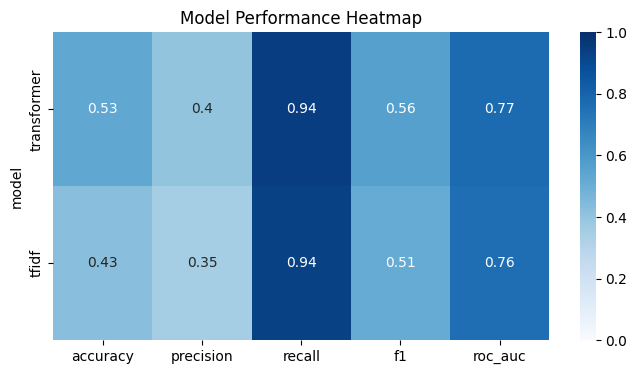

In [8]:
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.heatmap(
    df.set_index("model")[metrics],
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Model Performance Heatmap")
plt.show()

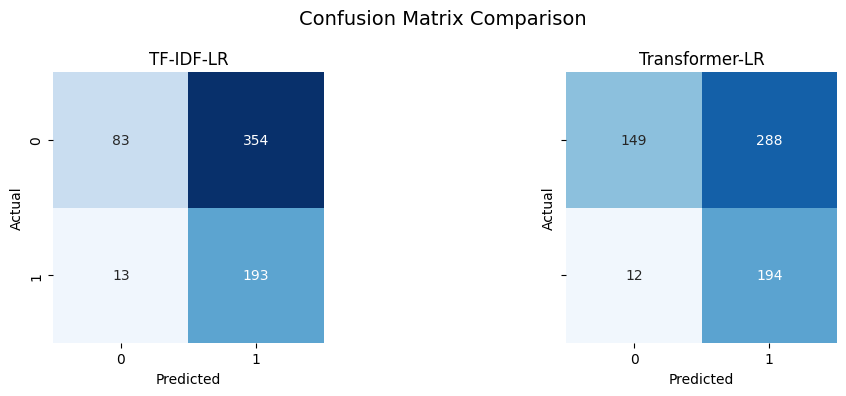

In [9]:


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

cms = [
    ("TF-IDF-LR", results_tfidf["confusion_matrix"]),
    ("Transformer-LR", results_transformer["confusion_matrix"])
]

vmax = max(cm.max() for _, cm in cms)  

for ax, (name, cm) in zip(axes, cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        cbar=False,
        square=True,
        ax=ax
    )
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

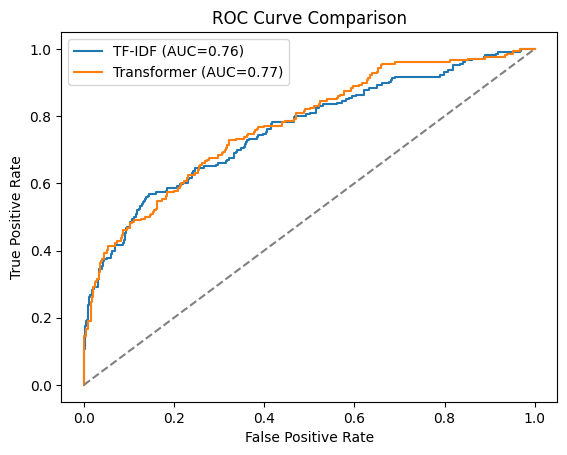

In [10]:
proba_tfidf = model_tfidf.predict_proba(X_test)[:, 1]
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, proba_tfidf)
auc_tfidf = roc_auc_score(y_test, proba_tfidf)
proba_tr = model_transformer.predict_proba(X_test)[:, 1]
fpr_tr, tpr_tr, _ = roc_curve(y_test, proba_tr)
auc_tr = roc_auc_score(y_test, proba_tr)

plt.plot(fpr_tfidf, tpr_tfidf, label=f"TF-IDF (AUC={auc_tfidf:.2f})")
plt.plot(fpr_tr, tpr_tr, label=f"Transformer (AUC={auc_tr:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()